# Analysis of Star Cluster NGC 362 using Gaia Data

## Scientific Background
**NGC 362** is a globular cluster located in the constellation Tucana, at a distance of about 8.6 kpc from the Sun. It is one of the most metal-rich globular clusters in the Milky Way, with an age of approximately 10–12 Gyr. Studying its stellar population helps understand the formation and evolution of globular clusters and the Galactic halo.

The data used in this notebook are from the **Gaia mission**, which provides precise astrometry (positions, proper motions, parallaxes) and photometry for over a billion stars. The catalog contains measurements of stars in the direction of NGC 362, including likely cluster members and field stars.

The columns include:
- `source_id`: Unique Gaia source identifier
- `ra`, `dec`: Right ascension and declination (J2015.5)
- `x`, `y`: Possibly pixel coordinates from the detector
- `plx`: Parallax (mas)
- `pmra`, `pmdec`: Proper motions in right ascension and declination (mas/yr)
- `plxe`, `pmrae`, `pmdece`: Uncertainties
- `pmcorr`: Correlation between proper motion errors
- `g_mag`: G-band magnitude
- `bp_rp`: BP-RP color index
- `Sigma`: Possibly a quality or sigma clipping parameter
- `qflag`: Quality flag
- `memberprob`: Membership probability of being a cluster member
 
The aim of this notebook is to explore the cluster's properties, identify cluster members, and construct color-magnitude diagrams to study the stellar populations.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import statistics
import matplotlib as mpl
from matplotlib import gridspec
from matplotlib.colorbar import Colorbar
from astropy.table import QTable


%matplotlib notebook

In [2]:
data = QTable.read('clusters/catalogues/NGC_362.txt', format='ascii.commented_header')
data

source_id,ra,dec,x,y,plx,pmra,pmdec,plxe,pmrae,pmdece,pmcorr,g_mag,bp_rp,Sigma,qflag,memberprob
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64
4690814301164802560,15.470036,-71.014712,-0.1104,-0.1662,-0.7385,6.6965,-1.3729,0.5124,0.5838,0.5098,-0.0682,20.2278,0.884,11.32,3,0.88059
4690814296867852288,15.460118,-71.012631,-0.1136,-0.1642,-0.0493,-1.265,1.0434,0.7108,0.8815,0.9478,-0.1207,20.5289,0.2865,11.33,0,0.0
4690814369886881536,15.446788,-71.009567,-0.118,-0.1611,0.5268,0.8755,-4.4265,1.4104,1.7175,2.0499,0.3086,20.8439,0.8838,11.34,2,0.00574
4690814301167665280,15.453017,-71.011278,-0.116,-0.1628,0.9815,1.1294,-2.484,1.1685,1.796,1.5774,-0.0887,20.8146,0.412,11.36,3,0.00498
4690814369885624704,15.464506,-71.005155,-0.1123,-0.1567,-0.2308,1.145,-1.4918,0.9012,0.9512,0.9452,-0.2694,20.6432,0.7112,10.56,2,0.0
4690814743544506752,15.415422,-70.997921,-0.1283,-0.1496,-0.1915,0.921,-1.2349,0.2134,0.2607,0.2444,-0.1736,19.204,0.7795,11.03,3,0.0
4690813991928174720,15.424805,-71.003719,-0.1252,-0.1553,0.5545,-1.2294,-10.774,0.5136,0.6319,0.6502,-0.279,20.2261,2.102,11.31,0,0.0
4690814369884278144,15.436813,-71.000814,-0.1213,-0.1524,-0.6041,1.4724,-2.2896,0.5455,0.7026,0.7015,-0.1939,20.3701,0.1178,10.76,3,0.0
4690814369885625984,15.452812,-70.998123,-0.1161,-0.1497,0.117,5.7813,-1.2941,0.8288,1.2535,1.0477,-0.2343,20.5095,0.7835,10.42,3,0.91034


## Data Exploration

We now have the data loaded. We will construct a color-magnitude diagrams (e.g., G vs BP-RP) to identify main sequence, red giant branch, etc.


<IPython.core.display.Javascript object>


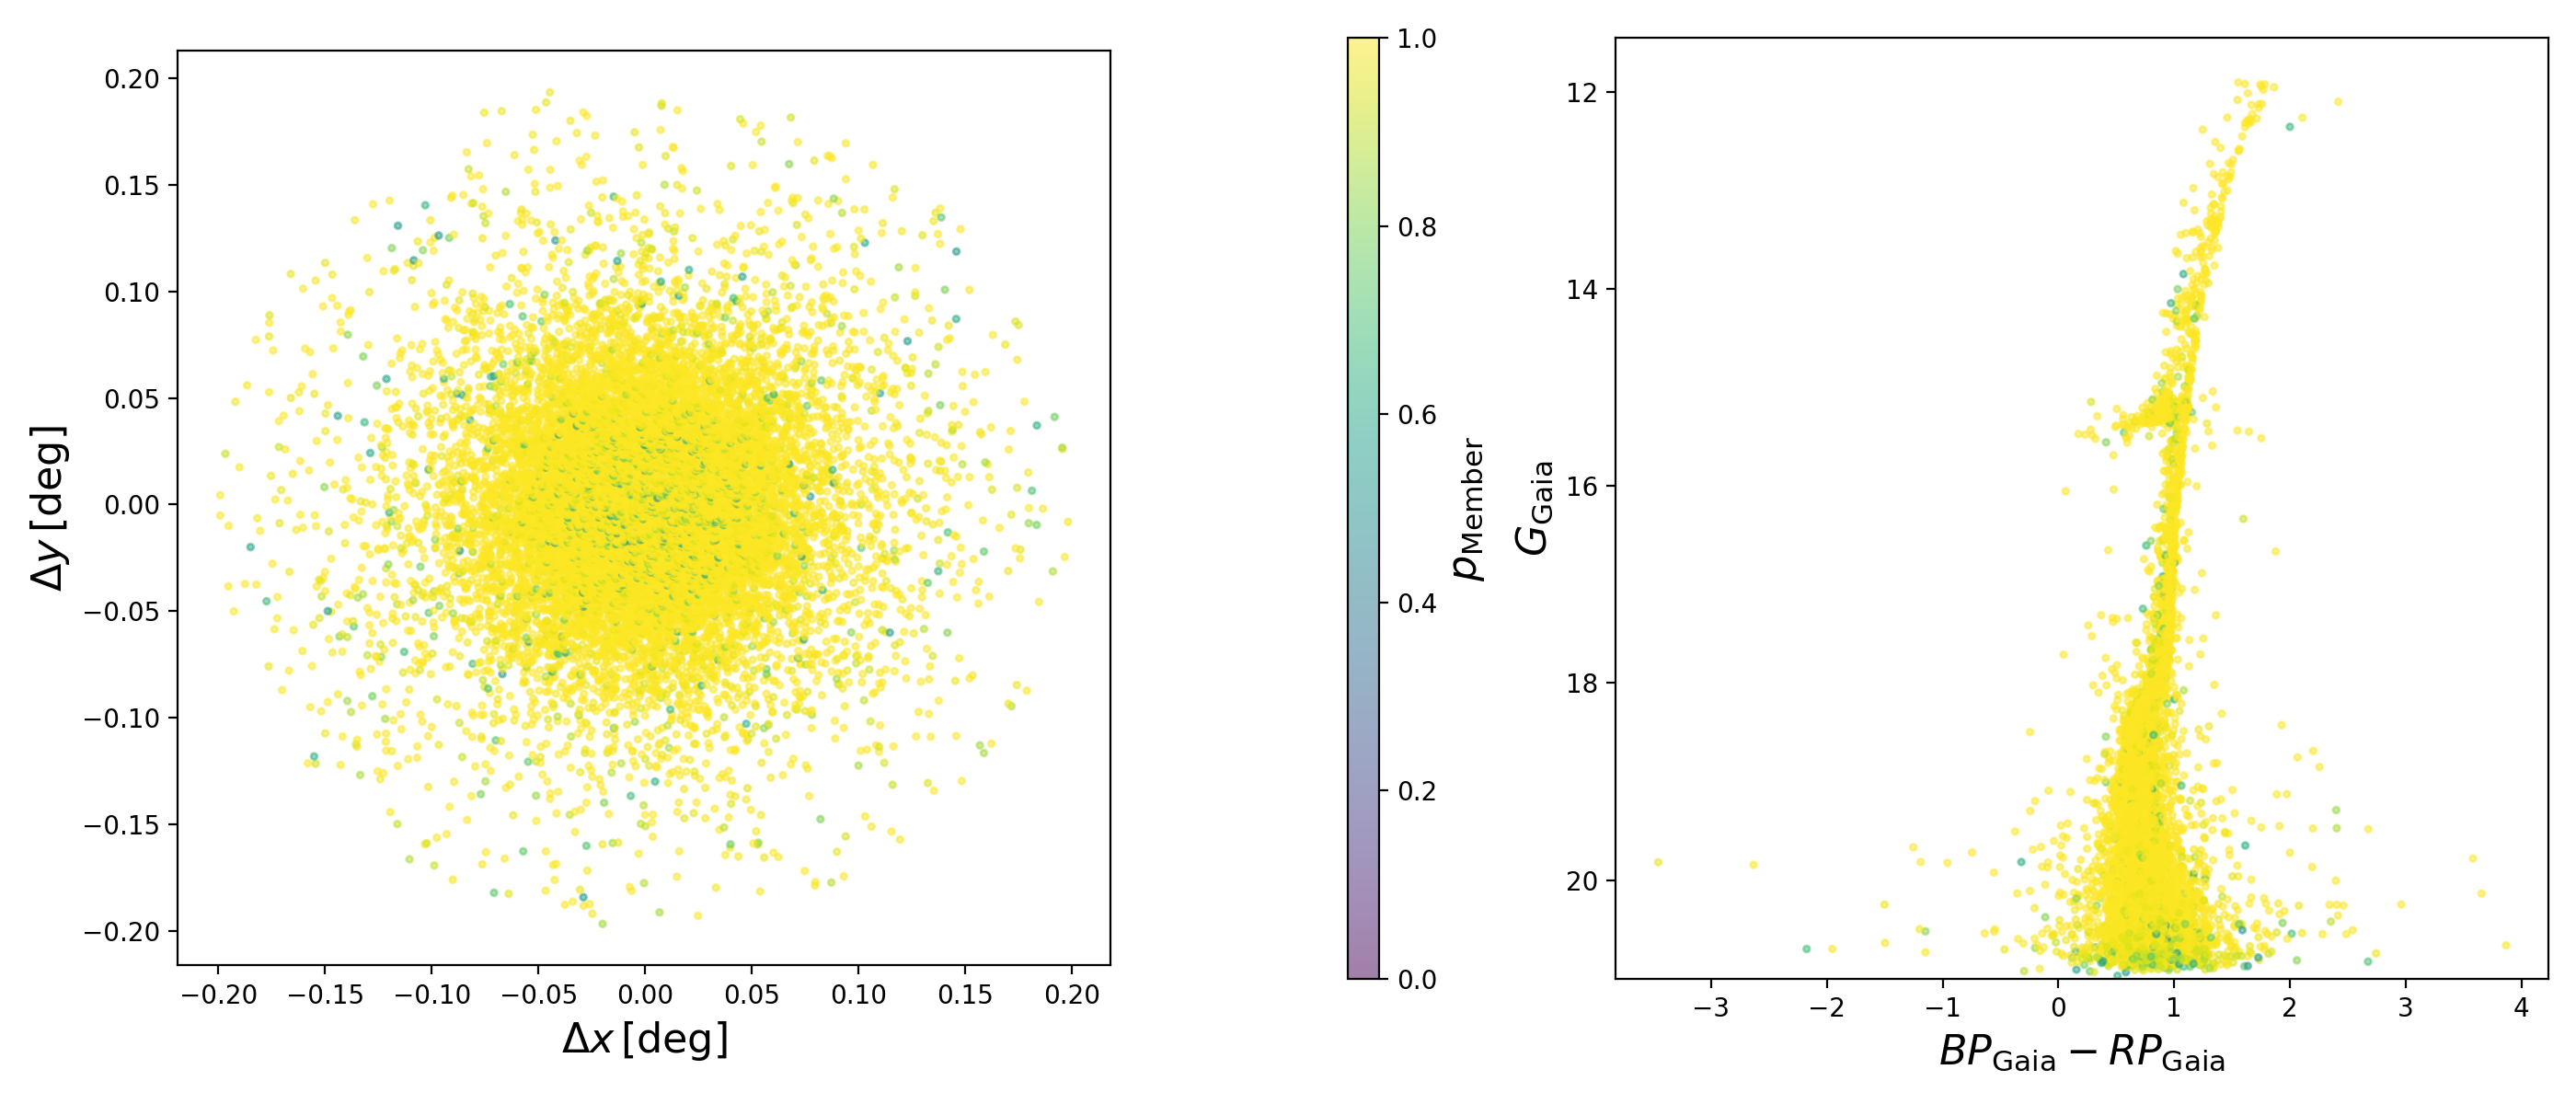

In [6]:
fig = plt.figure(figsize=(14, 6))
gs = gridspec.GridSpec(1, 3, width_ratios=(15, 0.5, 15))

only_members = True
if only_members:
    slc = data['memberprob'] > 0.5
else:
    slc = np.ones(len(data), dtype='bool')
    
ax_xy = fig.add_subplot(gs[0], aspect='equal')
xy_plot = ax_xy.scatter(data['x'][slc], data['y'][slc], marker='o', s=6, alpha=0.5, c=data['memberprob'][slc], cmap=plt.cm.viridis, vmin=0, vmax=1)
ax_xy.set_xlabel(r'$\Delta x\,[{\rm deg}]$', fontsize=16)
ax_xy.set_ylabel(r'$\Delta y\,[{\rm deg}]$', fontsize=16)



ax_cbar = fig.add_subplot(gs[1])
cbar = Colorbar(mappable=xy_plot, ax=ax_cbar, orientation='vertical')
ax_cbar.set_ylabel(r'$p_{\rm Member}$', fontsize=16)


ax_cmd = fig.add_subplot(gs[2])
ax_cmd.scatter(data['bp_rp'][slc], data['g_mag'][slc], marker='o', s=6, alpha=0.5, c=data['memberprob'][slc], cmap=plt.cm.viridis, vmin=0, vmax=1)

ax_cmd.set_ylim((21, ax_cmd.get_ylim()[0]))
ax_cmd.set_xlabel(r'$BP_{\rm Gaia}-RP_{\rm Gaia}$', fontsize=16)
ax_cmd.set_ylabel(r'$G_{\rm Gaia}$', fontsize=16)


fig.tight_layout()

##  Radial Density Distribution
Compute and plot the surface density of stars (all and member stars) as a function of radius. This helps identify the inner radius where Gaia becomes incomplete.

<IPython.core.display.Javascript object>


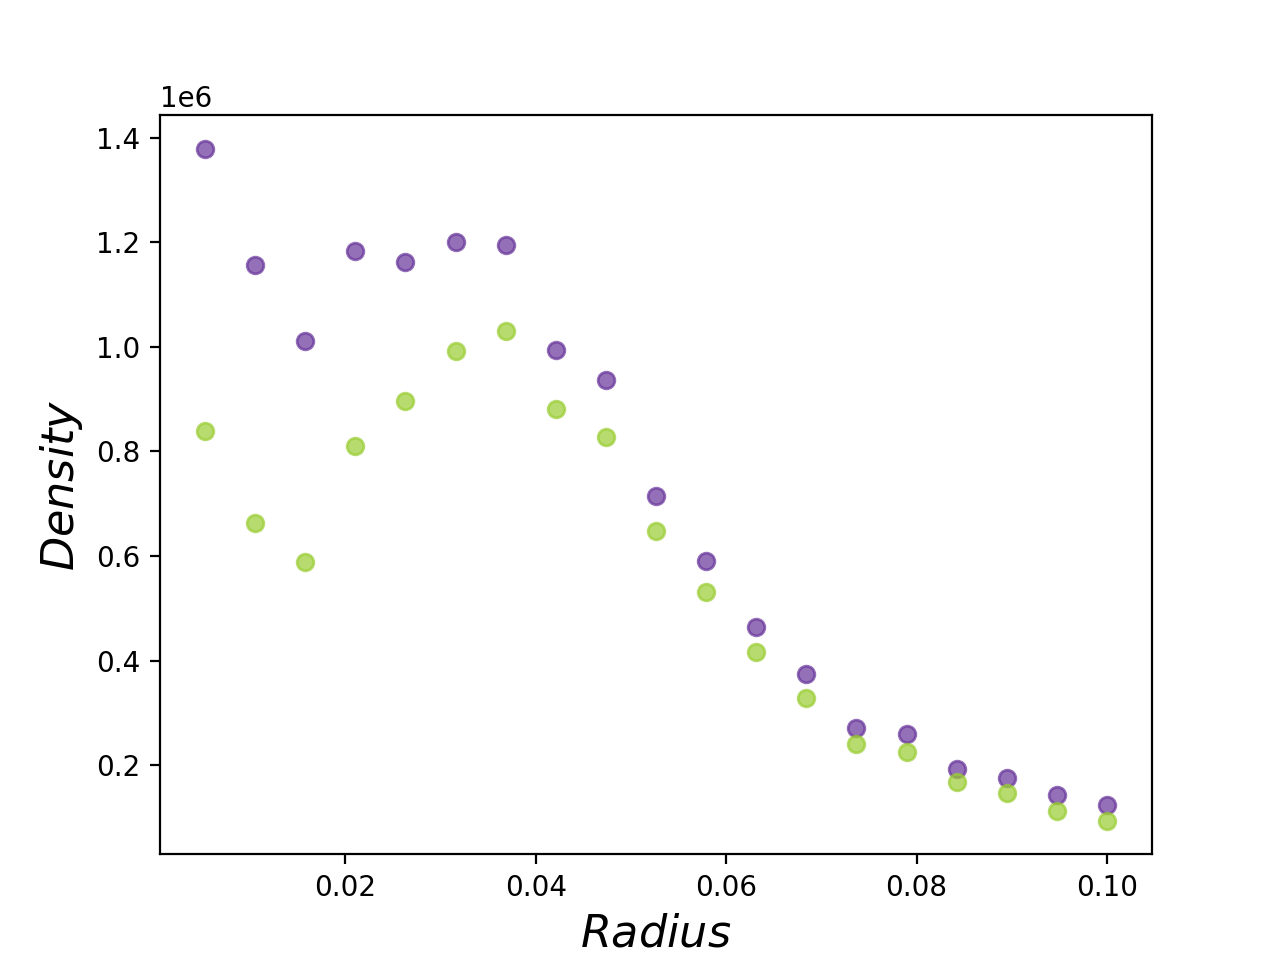

In [7]:
fig, ax = plt.subplots()

r_data = np.sqrt(data['x']**2 + data['y']**2)

radii = np.linspace(0, 0.1, 20)

for i, r in enumerate (radii[:-1]):
    in_bin = (r_data > r) & (r_data < radii[i+1])
    n_stars = in_bin.sum()
    area = np.pi*(radii[i+1]**2 - r**2)
    density = n_stars/area
    plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))
    plt.scatter(radii[i+1], density, marker='o', color='rebeccapurple', alpha=0.7, label = "all stars")
    


only_members = True
if only_members:
    slc = data['memberprob'] > 0.5
else:
    slc = np.ones(len(data), dtype='bool')
    
r_mem = np.sqrt((data['x'][slc])**2 + (data['y'][slc])**2)

for i, r in enumerate (radii[:-1]):
    in_bin = (r_mem > r) & (r_mem < radii[i+1])
    n_mem = in_bin.sum()
    area = np.pi*(radii[i+1]**2 - r**2)
    density_mem = n_mem/area
    plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))
    plt.scatter(radii[i+1], density_mem, marker = 'o', alpha=0.7, color = 'yellowgreen', label = "member stars")
    
    
    plt.xlabel("$ Radius $", fontsize=16)
    plt.ylabel("$ Density $", fontsize=16)


    plt.show()

## Ellipticity & Position Angle Calculation
Define the function that computes ellipticity and position angle from the covariance matrix, then apply it in radial bins and estimate uncertainties via bootstrapping.

<IPython.core.display.Javascript object>


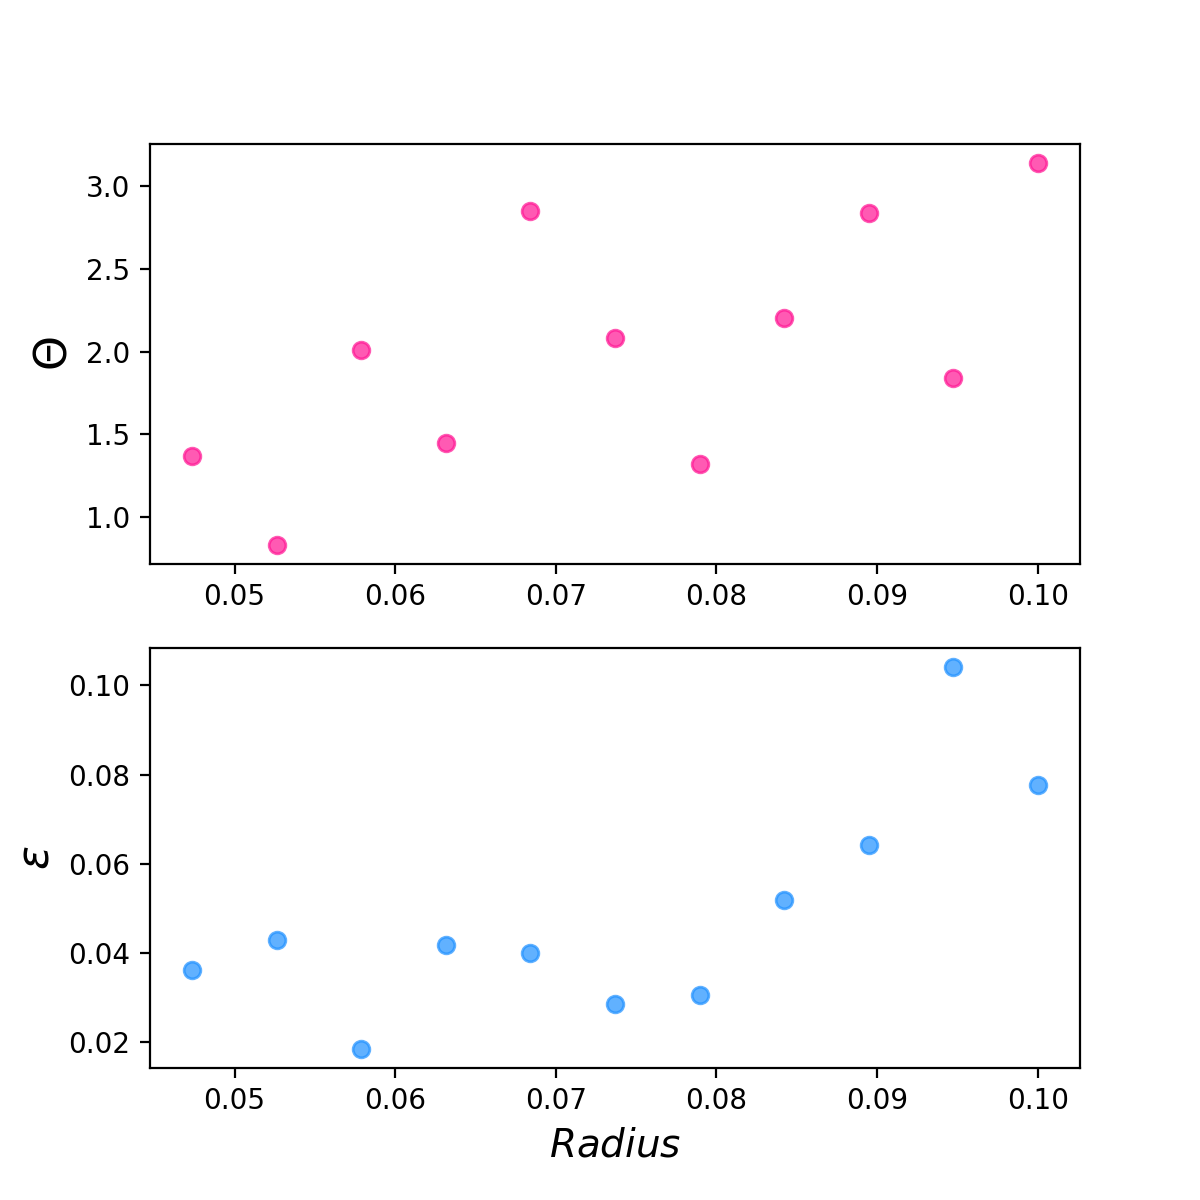

[1.370479293941369, 0.832838475394805, 2.0108103348749156, 1.4507825308986806, 2.847531953551717, 2.0847922211212975, 1.32019688727285, 2.204664486480926, 2.839799927480838, 1.8437503377580853, 3.1392022833704827]
1.994986248376906
[0.036170381656217776, 0.04295328106603746, 0.018543351172591205, 0.04181593458223143, 0.040007323348562274, 0.028582202593334327, 0.030640091822916493, 0.051989436260270194, 0.06421428884429026, 0.10408036375651752, 0.07758293172745212]
0.04877996243912919


In [5]:
fig, (ax1, ax2) = plt.subplots(2, figsize=(6,6))

def get_ellipse(dx, dy):
    """Returns position angle and ellipticity of a 2D distribution of points"""

    assert(len(dx) == len(dy))
    n = len(dx)
    
    # calculate covariance matrix
    cov = np.array([[np.sum(dx*dx)/n, np.sum(dx*dy)/n],
                [np.sum(dy*dx)/n, np.sum(dy*dy)/n]])

    # the eigenvalues are w, the eigenvectors are v
    w, v = np.linalg.eig(cov)

    # the eigenvalues are related to the semi-major and minor axis of the ellipse as follows:
    i = w.argmax() 
    j = w.argmin()
    

    # max(w) = 1/b**2, min(w) = 1/a**2
    # v[:, i] is eigenvector in direction of semi-major axis; subtract PI/2 to use +y instead +x as angle
    # zeropoint
    theta = np.arctan2(v[1, i], v[0, i]) - np.pi/2
    
    # fold negative axis angles to interval [0, PI]
    theta = np.mod(theta, np.pi)
    epsilon = 1 - np.sqrt(w[j]/w[i])
    

    return theta, epsilon

theta_values = []
epsilon_values = []

for f, r in enumerate (radii[:-1]):
    theta, epsilon = get_ellipse(data['x'], data['y'])    
    slc = data['memberprob'] > 0.5
    in_bin = (r_data > r) & (r_data < radii[f+1]) & slc
    n_stars = in_bin.sum()
    theta, epsilon = get_ellipse(data['x'][in_bin], data['y'][in_bin])

    
    if radii[f+1] > 0.044:
        theta_values.append((theta))
        epsilon_values.append((epsilon))
        ax1 = plt.subplot(211)
        ax1 = plt.scatter(radii[f+1], theta, marker='o', alpha=0.7, color='deeppink')
        ax1 = plt.ylabel("$\Theta $", fontsize=16)
        ax2 = plt.subplot(212)
        ax2 = plt.scatter(radii[f+1], epsilon, marker='o', alpha=0.7, color='dodgerblue')
        ax2 = plt.xlabel("$ Radius $", fontsize=14)
        ax2 = plt.ylabel("$\epsilon $", fontsize=16)
        
print(theta_values)
mean_theta = np.mean(theta_values)
print(mean_theta)
print(epsilon_values)
mean_epsilon = np.mean(epsilon_values)
print(mean_epsilon)

